# Marketing Campaign Analysis
## Phase 3 — Campaign performance analysis

**Data source:** marketing_db (PostgreSQL)
**Goal:** Use SQL to analyse campaign performance across acceptance rates, cost-efficiency, channel preference, and customer profiling. Identify which campaigns and customer segments drove the best response, and quantify what makes a campaign profitable.

### What this phase covers
- Acceptance rate per campaign (1–5 and the latest)
- **Break-even analysis** — what cost-per-contact and revenue-per-response a campaign needs to be profitable, given its acceptance rate
- Channel preference across customer spending tiers — what high-value customers buy where
- Detailed profile comparison: responders vs non-responders
- Response rate by education and marital status
- Multi-campaign engagement and top engaged customers
- Web channel behaviour — visits, purchases, and the real story behind web activity

### Note on cost / revenue data
The source dataset includes two placeholder columns (`Z_CostContact`, `Z_Revenue`) that are constant for every customer and carry no real cost or revenue signal. They were dropped during Phase 2. This phase therefore does **not** compute "actual ROI" — instead, the break-even analysis tells us what cost and revenue assumptions each campaign would need to be profitable in real-world deployment.

### How SQL and Python work together here
SQL handles aggregation, joins, filtering, and ranking. Python takes clean query results as DataFrames and handles visualisation. Every query is saved to `sql/queries/` for documentation and audit.

---
## 1. Import libraries & connect to database

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import getpass
import warnings
from pathlib import Path
from sqlalchemy import create_engine, text

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Locate the repo root portably by walking up from the current working
# directory until the 'data' folder is found, so the notebook runs on any
# machine and from any subfolder.
def find_project_root(marker='data'):
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"Could not find project root: no '{marker}/' folder above {Path.cwd()}. "
        "Run this notebook from inside the cloned repository."
    )

PROJECT_ROOT = find_project_root()
DOCS_PATH    = str(PROJECT_ROOT / 'docs')
SQL_PATH     = str(PROJECT_ROOT / 'sql' / 'queries')
os.makedirs(SQL_PATH, exist_ok=True)

# PostgreSQL connection — local trust authentication
username = getpass.getuser()
DB_URL   = f'postgresql+psycopg2://{username}@localhost:5432/marketing_db'
engine   = create_engine(DB_URL, future=True)

# Helper — runs a SQL query, returns a DataFrame, and saves the query for audit
def run_query(sql, name=None):
    if name:
        path = os.path.join(SQL_PATH, f'{name}.sql')
        with open(path, 'w') as f:
            f.write(sql.strip())
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

# Quick sanity check on the connection
test = run_query('SELECT COUNT(*) AS total_customers FROM customers')
print(f'Connected ✅ — {test["total_customers"].values[0]:,} customers in database')

Connected ✅ — 2,212 customers in database


---
## 2. Campaign acceptance rates
The most fundamental campaign metric — what proportion of customers accepted each offer? An `AVG()` of a 0/1 column gives the proportion directly, so we compute all six rates in a single query.

In [2]:
sql_acceptance = '''
SELECT
    -- AVG of a 0/1 column gives the proportion of 1s — multiply by 100 for percentage
    ROUND(AVG(accepted_cmp1) * 100, 2) AS campaign_1,
    ROUND(AVG(accepted_cmp2) * 100, 2) AS campaign_2,
    ROUND(AVG(accepted_cmp3) * 100, 2) AS campaign_3,
    ROUND(AVG(accepted_cmp4) * 100, 2) AS campaign_4,
    ROUND(AVG(accepted_cmp5) * 100, 2) AS campaign_5,
    ROUND(AVG(response)      * 100, 2) AS latest_campaign,
    COUNT(*) AS total_customers
FROM campaigns
'''

acceptance = run_query(sql_acceptance, 'campaign_acceptance_rates')
print('Campaign acceptance rates (%):')
print(acceptance.T.rename(columns={0: 'Value'}).to_string())

Campaign acceptance rates (%):
                   Value
campaign_1          6.42
campaign_2          1.36
campaign_3          7.37
campaign_4          7.41
campaign_5          7.28
latest_campaign    15.05
total_customers  2212.00


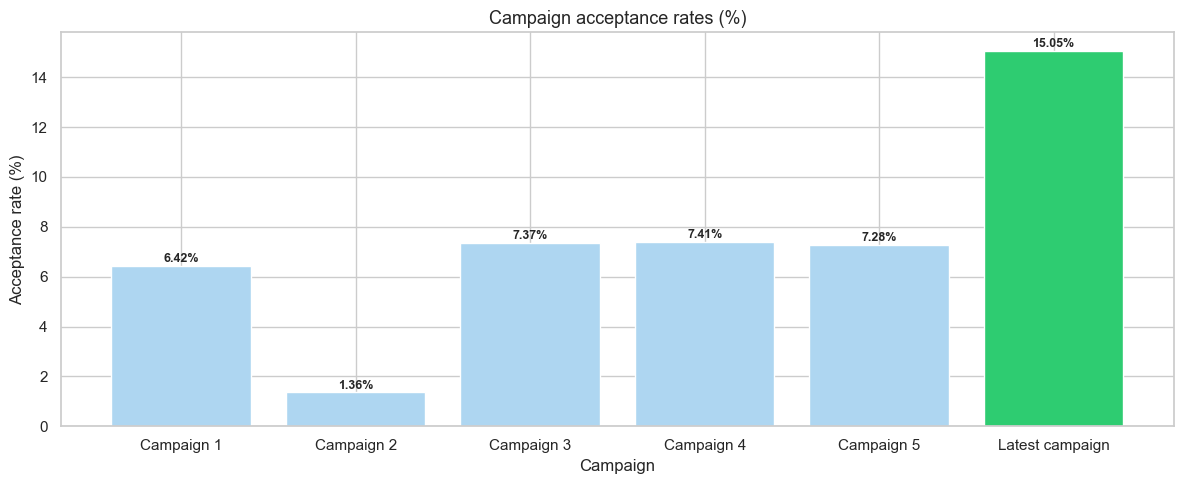

In [3]:
# Reshape to long format for plotting
cmp_labels = ['Campaign 1', 'Campaign 2', 'Campaign 3',
              'Campaign 4', 'Campaign 5', 'Latest campaign']
rates = acceptance[[
    'campaign_1', 'campaign_2', 'campaign_3',
    'campaign_4', 'campaign_5', 'latest_campaign'
]].values.flatten().astype(float)

acceptance_df = pd.DataFrame({
    'campaign': cmp_labels,
    'acceptance_rate': rates,
})

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#2ECC71' if r == rates.max() else '#AED6F1' for r in rates]
bars = ax.bar(acceptance_df['campaign'], acceptance_df['acceptance_rate'], color=bar_colors)
ax.set_title('Campaign acceptance rates (%)', fontsize=13)
ax.set_xlabel('Campaign')
ax.set_ylabel('Acceptance rate (%)')
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.15,
            f'{val}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p3_acceptance_rates.png'), dpi=150)
plt.show()

---
## 3. Campaign profitability — break-even analysis
Without real cost-per-contact and revenue-per-response data, we cannot compute actual ROI. What we **can** do is invert the question: given each campaign's observed acceptance rate, what cost/revenue ratio does it need to be profitable?

The break-even relationship is straightforward:

> **acceptance_rate × revenue_per_response = cost_per_contact**

Rearranging: a campaign breaks even when **revenue_per_response ≥ (1 / acceptance_rate) × cost_per_contact**. So a campaign with a 15% acceptance rate breaks even when revenue per response is ≥ 6.69× the cost per contact. The **lower this ratio, the more cost-efficient the campaign**.

In [4]:
sql_breakeven = '''
WITH campaign_rates AS (
    SELECT 'Campaign 1' AS campaign, AVG(accepted_cmp1)::NUMERIC AS rate, SUM(accepted_cmp1) AS responders FROM campaigns
    UNION ALL
    SELECT 'Campaign 2', AVG(accepted_cmp2)::NUMERIC, SUM(accepted_cmp2) FROM campaigns
    UNION ALL
    SELECT 'Campaign 3', AVG(accepted_cmp3)::NUMERIC, SUM(accepted_cmp3) FROM campaigns
    UNION ALL
    SELECT 'Campaign 4', AVG(accepted_cmp4)::NUMERIC, SUM(accepted_cmp4) FROM campaigns
    UNION ALL
    SELECT 'Campaign 5', AVG(accepted_cmp5)::NUMERIC, SUM(accepted_cmp5) FROM campaigns
    UNION ALL
    SELECT 'Latest campaign', AVG(response)::NUMERIC, SUM(response) FROM campaigns
)
SELECT
    campaign,
    responders,
    ROUND(rate * 100, 2)               AS acceptance_rate_pct,
    -- Minimum revenue : cost ratio needed to break even
    -- Lower = more efficient
    ROUND(1.0 / NULLIF(rate, 0), 2)    AS breakeven_revenue_cost_ratio
FROM campaign_rates
ORDER BY breakeven_revenue_cost_ratio ASC
'''

breakeven = run_query(sql_breakeven, 'campaign_breakeven')
print('Break-even analysis — most cost-efficient campaigns first:')
print(breakeven.to_string(index=False))

Break-even analysis — most cost-efficient campaigns first:
       campaign  responders  acceptance_rate_pct  breakeven_revenue_cost_ratio
Latest campaign         333                15.05                          6.64
     Campaign 4         164                 7.41                         13.49
     Campaign 3         163                 7.37                         13.57
     Campaign 5         161                 7.28                         13.74
     Campaign 1         142                 6.42                         15.58
     Campaign 2          30                 1.36                         73.73


In [5]:
# Plain-language interpretation of the break-even ratio
print('Interpretation:')
for _, row in breakeven.iterrows():
    print(f'  {row["campaign"]:<18}'
          f'breaks even when revenue per response ≥ '
          f'{row["breakeven_revenue_cost_ratio"]:>5.2f}× cost per contact')

Interpretation:
  Latest campaign   breaks even when revenue per response ≥  6.64× cost per contact
  Campaign 4        breaks even when revenue per response ≥ 13.49× cost per contact
  Campaign 3        breaks even when revenue per response ≥ 13.57× cost per contact
  Campaign 5        breaks even when revenue per response ≥ 13.74× cost per contact
  Campaign 1        breaks even when revenue per response ≥ 15.58× cost per contact
  Campaign 2        breaks even when revenue per response ≥ 73.73× cost per contact


In [6]:
# Scenario sensitivity — net profit per contact under three concrete cost/revenue scenarios
# This makes break-even tangible: stakeholder reads "at $2 cost / $25 revenue, this campaign earns X"
scenarios = [
    ('Conservative', 5.0, 20.0),  # $5 per contact, $20 per response
    ('Moderate',     3.0, 30.0),  # $3 per contact, $30 per response
    ('Optimistic',   2.0, 50.0),  # $2 per contact, $50 per response
]

scenario_results = breakeven[['campaign', 'acceptance_rate_pct']].copy()
for label, cost, revenue in scenarios:
    # Net profit per contact = (acceptance_rate × revenue) − cost
    net = (breakeven['acceptance_rate_pct'].astype(float) / 100 * revenue) - cost
    scenario_results[f'{label} (${cost:.0f}/${revenue:.0f})'] = net.round(2)

print('Net profit per contact under three cost/revenue scenarios ($):')
print('  (positive = profitable, negative = loss)')
print()
print(scenario_results.to_string(index=False))

Net profit per contact under three cost/revenue scenarios ($):
  (positive = profitable, negative = loss)

       campaign  acceptance_rate_pct  Conservative ($5/$20)  Moderate ($3/$30)  Optimistic ($2/$50)
Latest campaign                15.05                  -1.99               1.51                 5.52
     Campaign 4                 7.41                  -3.52              -0.78                 1.70
     Campaign 3                 7.37                  -3.53              -0.79                 1.68
     Campaign 5                 7.28                  -3.54              -0.82                 1.64
     Campaign 1                 6.42                  -3.72              -1.07                 1.21
     Campaign 2                 1.36                  -4.73              -2.59                -1.32


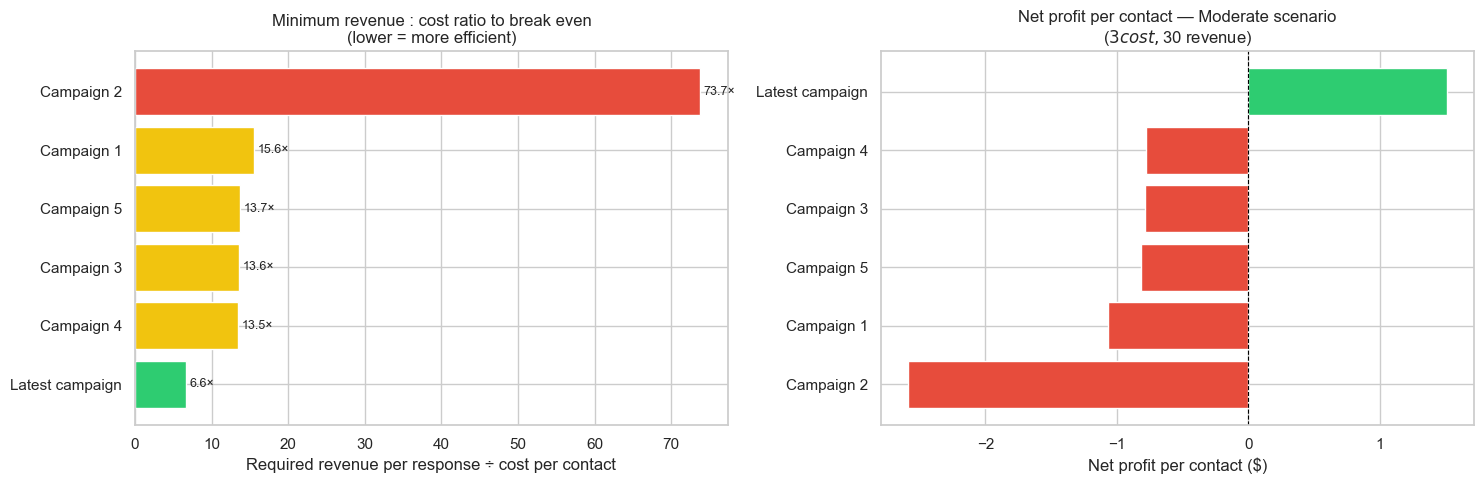

In [7]:
# Visualise the break-even ratio per campaign
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left — break-even ratio
order = breakeven.sort_values('breakeven_revenue_cost_ratio', ascending=True)
colors = ['#2ECC71' if v <= 10 else '#F1C40F' if v <= 25 else '#E74C3C'
          for v in order['breakeven_revenue_cost_ratio']]
axes[0].barh(order['campaign'], order['breakeven_revenue_cost_ratio'], color=colors)
axes[0].set_title('Minimum revenue : cost ratio to break even\n(lower = more efficient)', fontsize=12)
axes[0].set_xlabel('Required revenue per response ÷ cost per contact')
for i, (_, row) in enumerate(order.iterrows()):
    axes[0].text(row['breakeven_revenue_cost_ratio'] + 0.5, i,
                 f'{row["breakeven_revenue_cost_ratio"]:.1f}×',
                 va='center', fontsize=9)

# Right — net profit under the Moderate scenario
moderate_col = [c for c in scenario_results.columns if 'Moderate' in c][0]
moderate = scenario_results.sort_values(moderate_col, ascending=True)
colors2 = ['#2ECC71' if v > 0 else '#E74C3C' for v in moderate[moderate_col]]
axes[1].barh(moderate['campaign'], moderate[moderate_col], color=colors2)
axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title(f'Net profit per contact — Moderate scenario\n($3 cost, $30 revenue)', fontsize=12)
axes[1].set_xlabel('Net profit per contact ($)')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p3_breakeven_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Channel performance
Two questions: which channels do customers use most overall, and do high-spending customers use channels differently from low spenders?

In [8]:
sql_channels = '''
SELECT
    SUM(num_web_purchases)               AS web_total,
    SUM(num_store_purchases)             AS store_total,
    SUM(num_catalog_purchases)           AS catalog_total,
    SUM(num_deals_purchases)             AS deals_total,
    ROUND(AVG(num_web_purchases), 2)     AS web_avg,
    ROUND(AVG(num_store_purchases), 2)   AS store_avg,
    ROUND(AVG(num_catalog_purchases), 2) AS catalog_avg,
    ROUND(AVG(num_deals_purchases), 2)   AS deals_avg
FROM channels
'''

channel_summary = run_query(sql_channels, 'channel_totals')
print('Channel summary:')
print(channel_summary.T.rename(columns={0: 'Value'}).to_string())

Channel summary:
                  Value
web_total       9043.00
store_total    12844.00
catalog_total   5911.00
deals_total     5142.00
web_avg            4.09
store_avg          5.81
catalog_avg        2.67
deals_avg          2.32


In [9]:
# Channel preference by spending tier — NTILE(3) splits customers into 3 equal groups
# 1 = lowest spenders, 3 = highest spenders
sql_channel_by_tier = '''
WITH customer_tiers AS (
    SELECT
        s.customer_id,
        s.total_spend,
        NTILE(3) OVER (ORDER BY s.total_spend) AS spend_tier
    FROM spending s
)
SELECT
    CASE spend_tier
        WHEN 1 THEN 'Low spenders'
        WHEN 2 THEN 'Mid spenders'
        WHEN 3 THEN 'High spenders'
    END AS spend_tier,
    ROUND(AVG(ch.num_web_purchases), 2)     AS avg_web,
    ROUND(AVG(ch.num_store_purchases), 2)   AS avg_store,
    ROUND(AVG(ch.num_catalog_purchases), 2) AS avg_catalog,
    ROUND(AVG(ch.num_deals_purchases), 2)   AS avg_deals,
    COUNT(*) AS customer_count
FROM customer_tiers ct
JOIN channels ch ON ct.customer_id = ch.customer_id
GROUP BY spend_tier
ORDER BY MIN(ct.spend_tier)
'''

channel_tiers = run_query(sql_channel_by_tier, 'channel_by_spend_tier')
print('Channel preference by spending tier:')
print(channel_tiers.to_string(index=False))

Channel preference by spending tier:
   spend_tier  avg_web  avg_store  avg_catalog  avg_deals  customer_count
 Low spenders     1.58       2.83         0.29       1.77             738
 Mid spenders     5.01       6.00         2.07       3.21             737
High spenders     5.67       8.59         5.66       1.99             737


> **Key channel insight: catalog is the luxury channel.**
> High spenders use the catalog 20× more than low spenders (roughly 5.6 vs 0.3 average purchases). No other channel shows that kind of separation — store and web both scale roughly with spend, but catalog usage is heavily concentrated at the top of the spend distribution. Catalog activity is a stronger marker of high-value customers than any single channel volume metric.

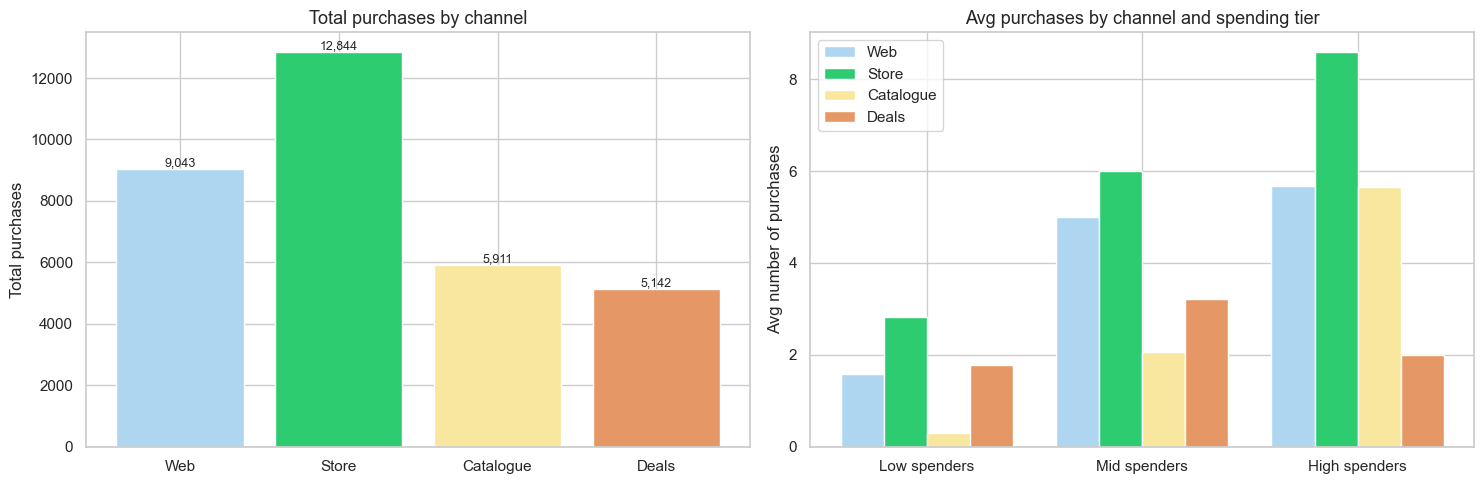

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total purchases by channel
channel_names = ['Web', 'Store', 'Catalogue', 'Deals']
totals = [
    channel_summary['web_total'].values[0],
    channel_summary['store_total'].values[0],
    channel_summary['catalog_total'].values[0],
    channel_summary['deals_total'].values[0],
]
bars = axes[0].bar(channel_names, totals,
                   color=['#AED6F1', '#2ECC71', '#F9E79F', '#E59866'])
axes[0].set_title('Total purchases by channel', fontsize=13)
axes[0].set_ylabel('Total purchases')
for bar, val in zip(bars, totals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{int(val):,}', ha='center', fontsize=9)

# Channel preference by spending tier — grouped bar
x = np.arange(len(channel_tiers))
width = 0.2
axes[1].bar(x - 1.5*width, channel_tiers['avg_web'],     width, label='Web',       color='#AED6F1')
axes[1].bar(x - 0.5*width, channel_tiers['avg_store'],   width, label='Store',     color='#2ECC71')
axes[1].bar(x + 0.5*width, channel_tiers['avg_catalog'], width, label='Catalogue', color='#F9E79F')
axes[1].bar(x + 1.5*width, channel_tiers['avg_deals'],   width, label='Deals',     color='#E59866')
axes[1].set_title('Avg purchases by channel and spending tier', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(channel_tiers['spend_tier'])
axes[1].set_ylabel('Avg number of purchases')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p3_channel_performance.png'), dpi=150)
plt.show()

---
## 5. Responder vs non-responder profiling
What distinguishes customers who accepted the latest campaign from those who didn't? This is the foundation for Phase 4's propensity model — the features with the biggest gap here are the ones most likely to predict response.

Note: `total_hist_campaigns_accepted` is used here. It sums only the 5 historical campaigns and excludes `response` (the target), so it is leakage-safe.

In [11]:
sql_profile = '''
SELECT
    CASE ca.response
        WHEN 1 THEN 'Responded'
        ELSE 'Did not respond'
    END                                                     AS response_group,
    COUNT(*)                                                AS customer_count,
    ROUND(AVG(cu.age)::NUMERIC, 1)                          AS avg_age,
    ROUND(AVG(cu.income)::NUMERIC, 0)                       AS avg_income,
    ROUND(AVG(s.total_spend)::NUMERIC, 0)                   AS avg_total_spend,
    ROUND(AVG(s.mnt_wines)::NUMERIC, 0)                     AS avg_wine_spend,
    ROUND(AVG(s.mnt_meat)::NUMERIC, 0)                      AS avg_meat_spend,
    ROUND(AVG(ch.total_purchases)::NUMERIC, 1)              AS avg_total_purchases,
    ROUND(AVG(ch.num_web_purchases)::NUMERIC, 1)            AS avg_web_purchases,
    ROUND(AVG(ch.num_catalog_purchases)::NUMERIC, 1)        AS avg_catalog_purchases,
    ROUND(AVG(ch.num_store_purchases)::NUMERIC, 1)          AS avg_store_purchases,
    ROUND(AVG(cu.recency)::NUMERIC, 1)                      AS avg_recency_days,
    ROUND(AVG(cu.tenure_days)::NUMERIC, 0)                  AS avg_tenure_days,
    ROUND(AVG(cu.total_children)::NUMERIC, 2)               AS avg_children,
    ROUND(AVG(ca.total_hist_campaigns_accepted)::NUMERIC, 2) AS avg_past_campaigns_accepted
FROM campaigns ca
JOIN customers cu ON ca.customer_id = cu.customer_id
JOIN spending  s  ON ca.customer_id = s.customer_id
JOIN channels  ch ON ca.customer_id = ch.customer_id
GROUP BY ca.response
ORDER BY ca.response DESC
'''

profile = run_query(sql_profile, 'responder_profile')
print('Responder vs non-responder profile:')
print(profile.T.to_string())

Responder vs non-responder profile:
                                     0                1
response_group               Responded  Did not respond
customer_count                     333             1879
avg_age                           44.5             45.2
avg_income                     60210.0          50497.0
avg_total_spend                  986.0            540.0
avg_wine_spend                   503.0            270.0
avg_meat_spend                   294.0            145.0
avg_total_purchases               17.7             14.4
avg_web_purchases                  5.1              3.9
avg_catalog_purchases              4.2              2.4
avg_store_purchases                6.1              5.8
avg_recency_days                  35.3             51.5
avg_tenure_days                  448.0            337.0
avg_children                      0.65              1.0
avg_past_campaigns_accepted       0.99             0.18


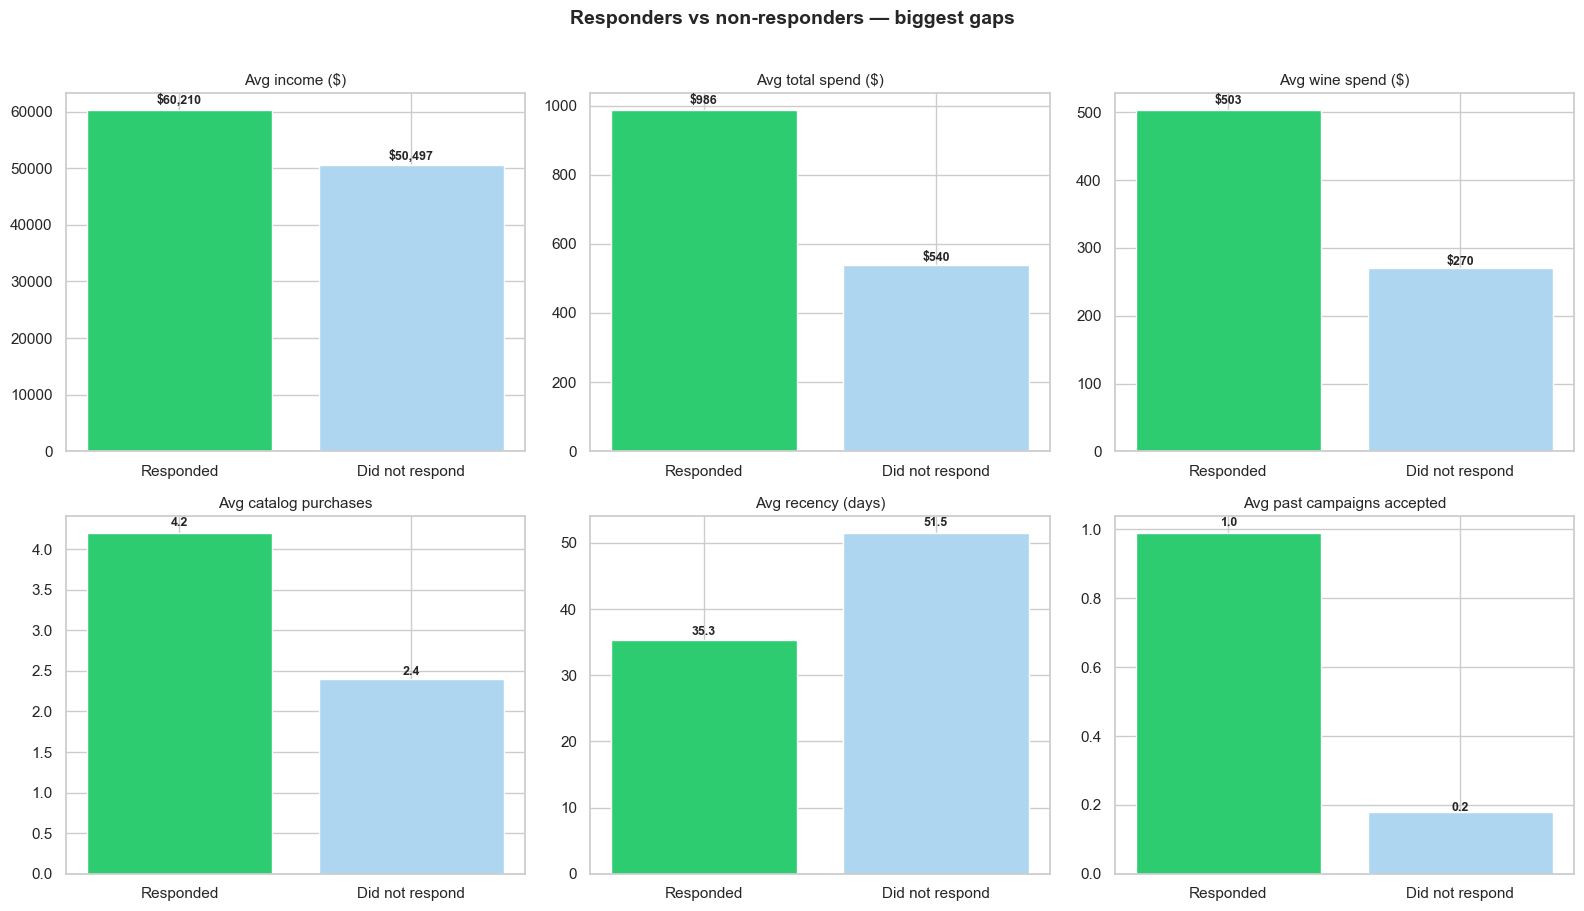

In [12]:
# Visualise the differences across the most discriminating metrics
metrics = {
    'Avg income ($)':              ('avg_income', '$'),
    'Avg total spend ($)':         ('avg_total_spend', '$'),
    'Avg wine spend ($)':          ('avg_wine_spend', '$'),
    'Avg catalog purchases':       ('avg_catalog_purchases', ''),
    'Avg recency (days)':          ('avg_recency_days', ''),
    'Avg past campaigns accepted': ('avg_past_campaigns_accepted', ''),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
groups = profile['response_group'].tolist()
colors = ['#2ECC71', '#AED6F1']

for i, (label, (col, prefix)) in enumerate(metrics.items()):
    vals = profile[col].astype(float).tolist()
    bars = axes[i].bar(groups, vals, color=colors)
    axes[i].set_title(label, fontsize=11)
    for bar, val in zip(bars, vals):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.02,
            f'{prefix}{val:,.1f}' if val % 1 else f'{prefix}{int(val):,}',
            ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Responders vs non-responders — biggest gaps',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p3_responder_profile.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Response rate by education and marital status
Do demographic factors influence who accepts campaigns?

In [13]:
sql_demo = '''
SELECT
    cu.education,
    COUNT(*)                            AS total_customers,
    SUM(ca.response)                    AS total_responses,
    ROUND(AVG(ca.response) * 100, 2)    AS response_rate_pct,
    ROUND(AVG(s.total_spend), 0)        AS avg_spend
FROM customers cu
JOIN campaigns ca ON cu.customer_id = ca.customer_id
JOIN spending  s  ON cu.customer_id = s.customer_id
GROUP BY cu.education
ORDER BY response_rate_pct DESC
'''

demo_education = run_query(sql_demo, 'response_by_education')
print('Response rate by education:')
print(demo_education.to_string(index=False))

Response rate by education:
    education  total_customers  total_responses  response_rate_pct  avg_spend
          PhD              480              101              21.04      674.0
       Master              365               56              15.34      610.0
   Graduation             1115              152              13.63      622.0
Undergraduate              198               22              11.11      499.0
        Basic               54                2               3.70       82.0


In [14]:
sql_marital = '''
SELECT
    cu.marital_status,
    COUNT(*)                            AS total_customers,
    SUM(ca.response)                    AS total_responses,
    ROUND(AVG(ca.response) * 100, 2)    AS response_rate_pct,
    ROUND(AVG(s.total_spend), 0)        AS avg_spend
FROM customers cu
JOIN campaigns ca ON cu.customer_id = ca.customer_id
JOIN spending  s  ON cu.customer_id = s.customer_id
GROUP BY cu.marital_status
ORDER BY response_rate_pct DESC
'''

demo_marital = run_query(sql_marital, 'response_by_marital_status')
print('Response rate by marital status:')
print(demo_marital.to_string(index=False))

Response rate by marital status:
marital_status  total_customers  total_responses  response_rate_pct  avg_spend
         Widow               76               18              23.68      728.0
        Single              477              109              22.85      613.0
      Divorced              231               48              20.78      613.0
       Married              857               98              11.44      591.0
      Together              571               60              10.51      608.0


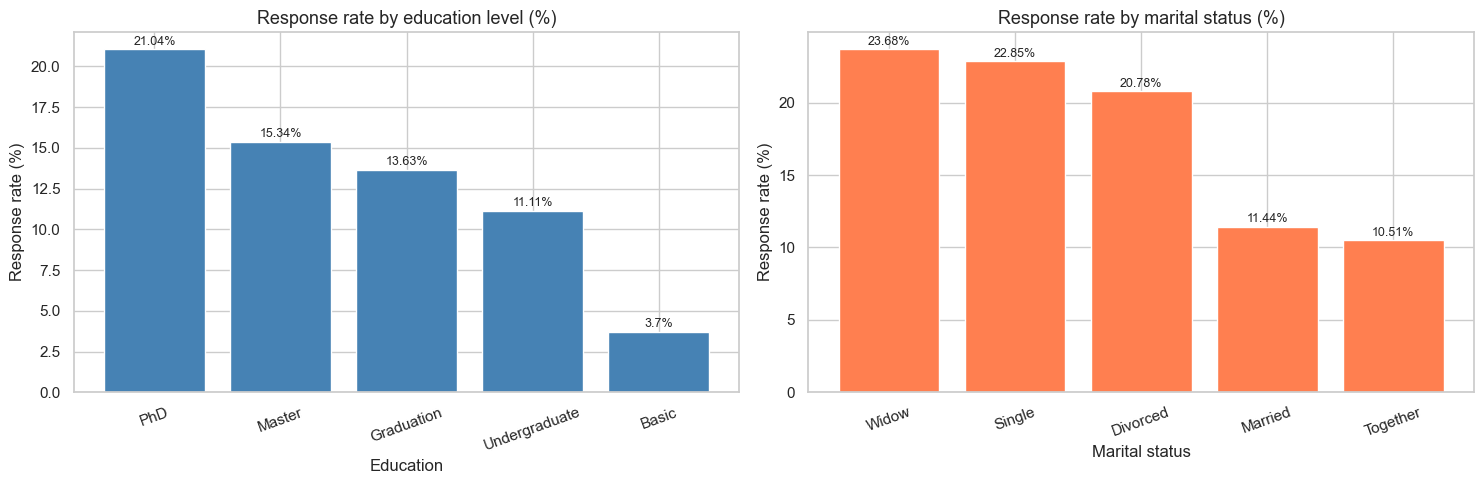

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(demo_education['education'], demo_education['response_rate_pct'], color='steelblue')
axes[0].set_title('Response rate by education level (%)', fontsize=13)
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Response rate (%)')
axes[0].tick_params(axis='x', rotation=20)
for i, (_, row) in enumerate(demo_education.iterrows()):
    axes[0].text(i, row['response_rate_pct'] + 0.3,
                 f'{row["response_rate_pct"]}%', ha='center', fontsize=9)

axes[1].bar(demo_marital['marital_status'], demo_marital['response_rate_pct'], color='coral')
axes[1].set_title('Response rate by marital status (%)', fontsize=13)
axes[1].set_xlabel('Marital status')
axes[1].set_ylabel('Response rate (%)')
axes[1].tick_params(axis='x', rotation=20)
for i, (_, row) in enumerate(demo_marital.iterrows()):
    axes[1].text(i, row['response_rate_pct'] + 0.3,
                 f'{row["response_rate_pct"]}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p3_demographics_response.png'), dpi=150)
plt.show()

---
## 7. Multi-campaign engagement
How many customers accept multiple campaigns? Multi-campaign acceptors are the most reliable response base — but how big is that segment, and how much more do they spend?

In [16]:
sql_engagement = '''
-- Distribution of historical campaign engagement (campaigns 1–5)
SELECT
    total_hist_campaigns_accepted                                AS campaigns_accepted,
    COUNT(*)                                                     AS customer_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2)           AS pct_of_customers
FROM campaigns
GROUP BY total_hist_campaigns_accepted
ORDER BY total_hist_campaigns_accepted
'''

engagement = run_query(sql_engagement, 'campaign_engagement_distribution')
print('Campaign engagement distribution:')
print(engagement.to_string(index=False))

Campaign engagement distribution:
 campaigns_accepted  customer_count  pct_of_customers
                  0            1754             79.29
                  1             322             14.56
                  2              81              3.66
                  3              44              1.99
                  4              11              0.50


In [17]:
# Top 10 most engaged customers ranked by historical campaigns accepted then spend
sql_top = '''
WITH ranked_customers AS (
    SELECT
        ca.customer_id,
        ca.total_hist_campaigns_accepted,
        ca.response AS latest_response,
        s.total_spend,
        cu.age,
        cu.education,
        cu.income,
        ROW_NUMBER() OVER (
            ORDER BY ca.total_hist_campaigns_accepted DESC,
                     s.total_spend DESC
        ) AS engagement_rank
    FROM campaigns ca
    JOIN spending  s  ON ca.customer_id = s.customer_id
    JOIN customers cu ON ca.customer_id = cu.customer_id
)
SELECT *
FROM ranked_customers
WHERE engagement_rank <= 10
ORDER BY engagement_rank
'''

top_customers = run_query(sql_top, 'top_engaged_customers')
print('Top 10 most engaged customers:')
print(top_customers.to_string(index=False))

Top 10 most engaged customers:
 customer_id  total_hist_campaigns_accepted  latest_response  total_spend  age  education   income  engagement_rank
         477                              4                1       2157.0   28 Graduation  83512.0                1
        3174                              4                1       1957.0   55 Graduation  87771.0                2
        5536                              4                1       1957.0   55 Graduation  87771.0                3
        8545                              4                1       1789.0   60 Graduation  85683.0                4
        3725                              4                1       1688.0   53        PhD  84865.0                5
        3138                              4                1       1676.0   58 Graduation  91249.0                6
        5067                              4                0       1378.0   20 Graduation  80134.0                7
        5758                             

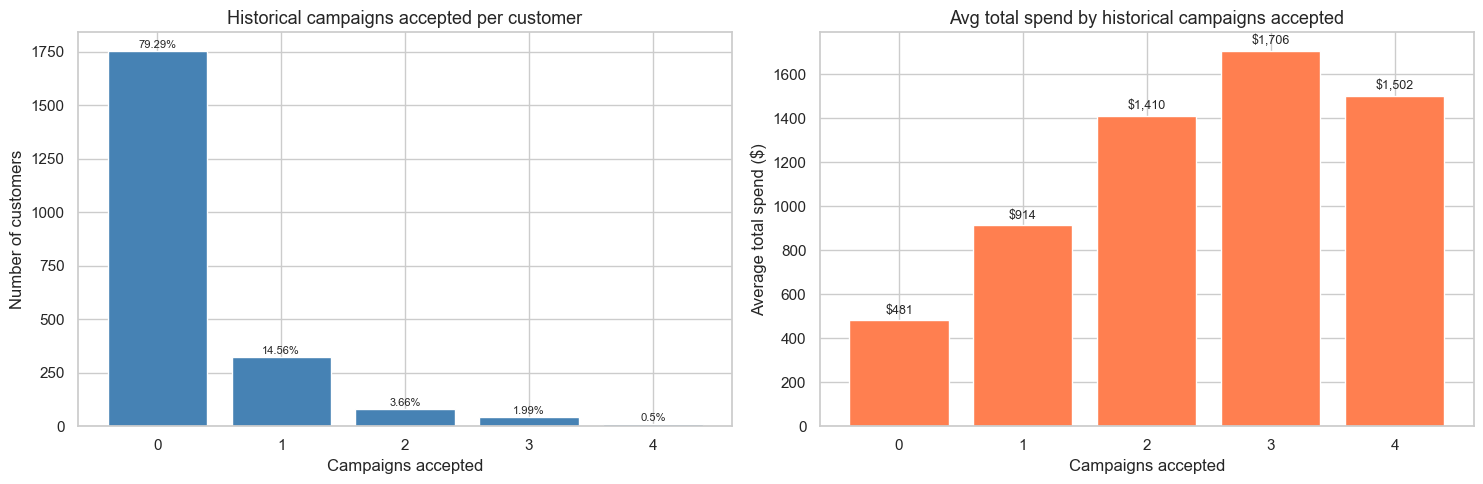

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Engagement distribution
axes[0].bar(engagement['campaigns_accepted'].astype(str),
            engagement['customer_count'], color='steelblue')
axes[0].set_title('Historical campaigns accepted per customer', fontsize=13)
axes[0].set_xlabel('Campaigns accepted')
axes[0].set_ylabel('Number of customers')
for i, row in engagement.iterrows():
    axes[0].text(i, row['customer_count'] + 15,
                 f'{row["pct_of_customers"]}%', ha='center', fontsize=8)

# Avg spend by number of campaigns accepted
sql_spend_by_engagement = '''
SELECT
    ca.total_hist_campaigns_accepted,
    ROUND(AVG(s.total_spend), 0) AS avg_spend
FROM campaigns ca
JOIN spending s ON ca.customer_id = s.customer_id
GROUP BY ca.total_hist_campaigns_accepted
ORDER BY ca.total_hist_campaigns_accepted
'''
spend_engagement = run_query(sql_spend_by_engagement)
axes[1].bar(spend_engagement['total_hist_campaigns_accepted'].astype(str),
            spend_engagement['avg_spend'], color='coral')
axes[1].set_title('Avg total spend by historical campaigns accepted', fontsize=13)
axes[1].set_xlabel('Campaigns accepted')
axes[1].set_ylabel('Average total spend ($)')
for i, row in spend_engagement.iterrows():
    axes[1].text(i, row['avg_spend'] + 30,
                 f'${int(row["avg_spend"]):,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p3_engagement_analysis.png'), dpi=150)
plt.show()

---
## 8. Web channel — visit frequency vs purchase frequency
The web channel story isn't a conversion gap — almost everyone buys online at least sometimes. The real question is how often customers visit vs how often they actually purchase, and where the meaningful opportunity sits.

In [19]:
sql_web = '''
SELECT
    -- What proportion of customers buy online at all (over 2 years)?
    ROUND(
        SUM(CASE WHEN num_web_purchases > 0 THEN 1 ELSE 0 END)::NUMERIC
        / COUNT(*)::NUMERIC * 100, 2
    ) AS pct_who_buy_online,

    -- Average web visits per month
    ROUND(AVG(num_web_visits_month)::NUMERIC, 2)    AS avg_monthly_visits,

    -- Average web purchases (total, last 2 years)
    ROUND(AVG(num_web_purchases)::NUMERIC, 2)       AS avg_web_purchases_2yr,

    -- Implied purchase-per-visit ratio (assuming 24 months of visits at avg rate)
    ROUND(
        AVG(num_web_purchases)::NUMERIC
        / NULLIF(AVG(num_web_visits_month) * 24, 0)::NUMERIC,
        4
    ) AS implied_visit_to_purchase_ratio,

    -- Heavy visitors who never buy online — top web-opportunity segment
    SUM(CASE WHEN num_web_visits_month > 5 AND num_web_purchases = 0 THEN 1 ELSE 0 END) AS heavy_visitors_never_buy,

    -- Customers who never visit at all (likely store-loyal)
    SUM(CASE WHEN num_web_visits_month = 0 THEN 1 ELSE 0 END) AS never_visit,

    COUNT(*) AS total_customers
FROM channels
'''

web = run_query(sql_web, 'web_channel_analysis')
print('Web channel summary:')
print(web.T.rename(columns={0: 'Value'}).to_string())

Web channel summary:
                                    Value
pct_who_buy_online                 97.830
avg_monthly_visits                  5.320
avg_web_purchases_2yr               4.090
implied_visit_to_purchase_ratio     0.032
heavy_visitors_never_buy           20.000
never_visit                        10.000
total_customers                  2212.000


> **Reading the web channel data.**
> 97.8% of customers buy online at least once over the 2-year window. The story is not "customers don't convert" — it's that on average they visit the site frequently (5.3×/month) but only buy ~4× total over 24 months. So the web channel has high visit volume and low per-visit purchase intent. The actionable web segment is the small group of heavy visitors who never buy online — likely strong candidates for targeted web-only offers, but a small population.

---
## 9. Phase 3 summary

In [20]:
# Pull values dynamically from earlier results
best_campaign     = acceptance_df.loc[acceptance_df['acceptance_rate'].idxmax(), 'campaign']
best_rate         = acceptance_df['acceptance_rate'].max()
most_efficient    = breakeven.iloc[0]
least_efficient   = breakeven.iloc[-1]

responded     = profile[profile['response_group'] == 'Responded'].iloc[0]
not_responded = profile[profile['response_group'] == 'Did not respond'].iloc[0]
spend_lift    = round(
    (float(responded['avg_total_spend']) / float(not_responded['avg_total_spend']) - 1) * 100, 1
)

# Channel tier insight — catalog ratio between high and low spenders
high_catalog = float(channel_tiers[channel_tiers['spend_tier'] == 'High spenders']['avg_catalog'].values[0])
low_catalog  = float(channel_tiers[channel_tiers['spend_tier'] == 'Low spenders']['avg_catalog'].values[0])
catalog_ratio = round(high_catalog / max(low_catalog, 0.01), 1)

# Web channel
pct_buy_online       = float(web['pct_who_buy_online'].values[0])
heavy_never_buy      = int(web['heavy_visitors_never_buy'].values[0])
never_visit          = int(web['never_visit'].values[0])

print('=' * 64)
print('PHASE 3 SUMMARY — CAMPAIGN PERFORMANCE ANALYSIS')
print('=' * 64)
print()
print('--- Campaign performance ---')
print(f'Best acceptance rate:           {best_campaign} ({best_rate}%)')
print(f'Most cost-efficient campaign:   {most_efficient["campaign"]} (break-even at {most_efficient["breakeven_revenue_cost_ratio"]:.1f}× revenue:cost)')
print(f'Least cost-efficient campaign:  {least_efficient["campaign"]} (break-even at {least_efficient["breakeven_revenue_cost_ratio"]:.1f}× revenue:cost)')
print()
print('--- Responder profile ---')
print(f'Avg spend — responders:         ${float(responded["avg_total_spend"]):,.0f}')
print(f'Avg spend — non-responders:     ${float(not_responded["avg_total_spend"]):,.0f}')
print(f'Spend lift (responders):        +{spend_lift}%')
print(f'Avg past campaigns (responders):     {float(responded["avg_past_campaigns_accepted"]):.2f}')
print(f'Avg past campaigns (non-responders): {float(not_responded["avg_past_campaigns_accepted"]):.2f}')
print()
print('--- Channel insights ---')
print(f'Catalog is the luxury channel:  high spenders use it {catalog_ratio:.0f}× more than low spenders')
print(f'Web — customers who buy online: {pct_buy_online}%')
print(f'Web — heavy visitors never buy: {heavy_never_buy} customers (small opportunity segment)')
print(f'Web — never visit at all:       {never_visit} customers')
print()
print(f'--- SQL queries saved: {len(os.listdir(SQL_PATH))} files in sql/queries/ ---')
print()
print('Key takeaways for Phase 4 propensity modelling:')
print('  • Past campaign acceptance is the single strongest signal of future response')
print('  • Total spend, catalog purchases, and recency are the top behavioural features')
print('  • The latest campaign delivered double the acceptance rate of any historical')
print('    campaign — its targeting and creative are the model worth learning from.')
print('=' * 64)
print('\n✅ Phase 3 complete. Proceed to Phase 4 — CLV prediction & customer segmentation.')

PHASE 3 SUMMARY — CAMPAIGN PERFORMANCE ANALYSIS

--- Campaign performance ---
Best acceptance rate:           Latest campaign (15.05%)
Most cost-efficient campaign:   Latest campaign (break-even at 6.6× revenue:cost)
Least cost-efficient campaign:  Campaign 2 (break-even at 73.7× revenue:cost)

--- Responder profile ---
Avg spend — responders:         $986
Avg spend — non-responders:     $540
Spend lift (responders):        +82.6%
Avg past campaigns (responders):     0.99
Avg past campaigns (non-responders): 0.18

--- Channel insights ---
Catalog is the luxury channel:  high spenders use it 20× more than low spenders
Web — customers who buy online: 97.83%
Web — heavy visitors never buy: 20 customers (small opportunity segment)
Web — never visit at all:       10 customers

--- SQL queries saved: 25 files in sql/queries/ ---

Key takeaways for Phase 4 propensity modelling:
  • Past campaign acceptance is the single strongest signal of future response
  • Total spend, catalog purchases, a